In [1]:
import json
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as patches

dataset_path = '../FigureQA_Dataset/sample_train1'
annotations_file = os.path.join(dataset_path, 'annotations.json')
qa_file = os.path.join(dataset_path, 'qa_pairs.json')
images_dir = os.path.join(dataset_path, 'png')

## Preproccesing

Graph Type Counts:
type
vbar_categorical    200
hbar_categorical    200
line                200
pie                 200
dot_line            200
Name: count, dtype: int64


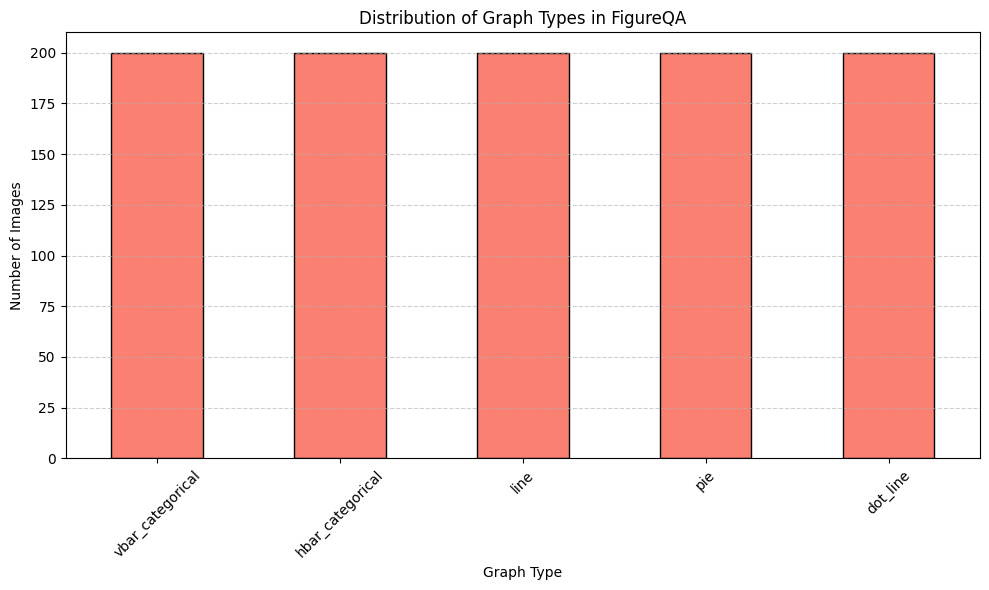

In [2]:
import pandas as pd

def get_graph_counts(file_path):
    # 1. Load the annotations
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # 2. Extract types (vbar_categorical, line, pie, etc.)
    graph_types = [item['type'] for item in data]
    
    # 3. Create a summary table
    df = pd.DataFrame(graph_types, columns=['type'])
    counts = df['type'].value_counts()
    
    print("Graph Type Counts:")
    print(counts)
    
    # 4. Visualize the distribution
    plt.figure(figsize=(10, 6))
    counts.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title("Distribution of Graph Types in FigureQA")
    plt.ylabel("Number of Images")
    plt.xlabel("Graph Type")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    # Save the plot for your records
    plt.savefig('dataset_distribution.png')
    plt.show()

# Run the analysis
get_graph_counts(annotations_file)

## Classify graph

In [3]:
output_dir = './classifier_data'

def prepare_folders():
    with open(annotations_file, 'r') as f:
        annotations = json.load(f)

    for item in annotations:
        img_idx = item['image_index']
        graph_type = item['type']
        
        # Create folder for each type if it doesn't exist
        type_dir = os.path.join(output_dir, graph_type)
        os.makedirs(type_dir, exist_ok=True)
        
        # Copy image to its respective type folder
        src = os.path.join(images_dir, f"{img_idx}.png")
        dst = os.path.join(type_dir, f"{img_idx}.png")
        if os.path.exists(src):
            shutil.copy(src, dst)

    print(f"Data organized into {output_dir}")

prepare_folders()

Data organized into ./classifier_data


In [4]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms

# 1. Define Image Transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Load organized data
dataset = datasets.ImageFolder(output_dir, transform=data_transforms)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

# 3. Initialize Pre-trained ResNet18
model = models.resnet18(pretrained=True)

# Freeze early layers so we only train the new head
for param in model.parameters():
    param.requires_grad = False

# Replace the last fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) # 5 = your number of graph types

print("Model ready for training.")

/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/aryangahlot/.pyenv/versions/tfenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/aryangahlot/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:01<00:00, 42.1MB/s]


Model ready for training.


In [7]:
import torch.optim as optim
import time

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 5 

print(f"Training started on {device}...")

for epoch in range(num_epochs):
    start_time = time.time()
    
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / train_size
    epoch_acc = running_corrects.float() / train_size

    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)
    
    val_acc = val_corrects.float() / val_size
    
    duration = time.time() - start_time
    print(f'Epoch {epoch+1}/{num_epochs} | '
          f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | '
          f'Val Acc: {val_acc:.4f} | Time: {duration:.0f}s')

torch.save(model.state_dict(), 'graph_classifier.pth')
print("\nFixed! Model saved as 'graph_classifier.pth'")

Training started on mps...
Epoch 1/5 | Train Loss: 0.0332 Acc: 0.9987 | Val Acc: 0.9950 | Time: 4s
Epoch 2/5 | Train Loss: 0.0167 Acc: 1.0000 | Val Acc: 0.9950 | Time: 3s
Epoch 3/5 | Train Loss: 0.0133 Acc: 1.0000 | Val Acc: 0.9950 | Time: 3s
Epoch 4/5 | Train Loss: 0.0099 Acc: 1.0000 | Val Acc: 0.9950 | Time: 3s
Epoch 5/5 | Train Loss: 0.0094 Acc: 1.0000 | Val Acc: 0.9950 | Time: 3s

Fixed! Model saved as 'graph_classifier.pth'


Class Mapping: ['dot_line', 'hbar_categorical', 'line', 'pie', 'vbar_categorical']


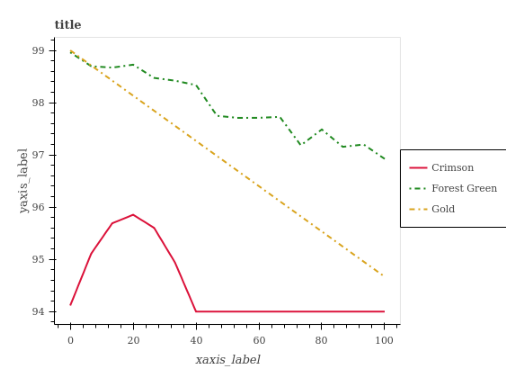


--- Vision System Output ---
Detected Graph Type: line
This is a line graph. I will now track the trends and slopes over time...


In [9]:
import torch
from PIL import Image
import random

# 1. Setup Class Mapping
# ImageFolder assigns indices alphabetically based on folder names
class_names = dataset.classes 
print(f"Class Mapping: {class_names}")

def predict_and_summarize(image_path):
    # --- Part A: Classification ---
    model.eval()
    img = Image.open(image_path).convert('RGB')
    
    # Preprocess the image exactly like training
    img_tensor = data_transforms(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(img_tensor)
        _, preds = torch.max(outputs, 1)
        predicted_type = class_names[preds[0]]

    print(f"\n--- Vision System Output ---")
    print(f"Detected Graph Type: {predicted_type}")

    # --- Part B: The Switch Logic ---
    # Here we use the classifier's output to choose the description style
    if predicted_type == "pie":
        # Placeholder for specific Pie logic
        return f"This is a Pie Chart. I will now analyze the slices and percentages..."
    
    elif "bar" in predicted_type:
        # Placeholder for Bar logic
        direction = "vertical" if "vbar" in predicted_type else "horizontal"
        return f"This is a {direction} bar chart. I will now compare the lengths of the categories..."
    
    elif "line" in predicted_type:
        # Placeholder for Line logic
        return f"This is a line graph. I will now track the trends and slopes over time..."
    
    else:
        return "Unknown graph type detected."

# 2. Test it on a random image from your original folder
random_idx = random.randint(0, 999)
test_image_path = os.path.join(images_dir, f"{random_idx}.png")

# Show the image
plt.imshow(Image.open(test_image_path))
plt.axis('off')
plt.show()

# Run the switch
print(predict_and_summarize(test_image_path))